# ESG Report Generation Based on Huazheng ESG Annual Rating Data

## ACC102 Mini Assignment – Track 3

This notebook demonstrates the Python workflow that supports an ESG report generation agent.  
The workflow uses the Huazheng ESG Annual Rating Database (2009–2024) to analyze a selected listed company based on stock code input.

The notebook includes:
- data loading
- data cleaning
- target company identification
- ESG trend analysis
- peer benchmarking
- visualization
- summary findings

## 1. Project Objective

The objective of this project is to transform raw ESG rating data into a structured and interpretable company-level ESG report.

The workflow is designed to support users such as:
- ESG-conscious investors
- business students
- sustainability researchers
- corporate analysts

The final product allows users to enter a stock code and receive an English ESG analysis report for the corresponding company.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Jupyter inline plot setting
%matplotlib inline
# Professional plot style (full compatibility)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('RdBu_r')
# 替换成下面这几行：
plt.rcParams['font.sans-serif'] = ['SimHei', 'WenQuanYi Zen Hei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# ==================================================
# 【全版本兼容修复：加载数据，彻底解决参数报错】
# ==================================================
file_path = r'C:\DeBruyne\华证指数esg 评级评分（年度） 2009-2024.xlsx'
# 去掉所有低版本不支持的参数，加载后再清洗空行
df = pd.read_excel(file_path, header=0)
# 手动删除全空行，兼容所有pandas版本
df = df.dropna(how='all').reset_index(drop=True)


## 2. Data Source

- **Dataset:** Huazheng ESG Annual Rating Database
- **Coverage Period:** 2009–2024
- **Scope:** Chinese A-share listed companies

This dataset contains company-level ESG information, including:
- company name
- stock code
- year
- ESG total score
- Environmental score
- Social score
- Governance score
- industry classification

In [6]:
# Print raw data overview
print("="*80)
print("=== 1. Data Source & Cleaning Report ===")
print("="*80)
print(f"Total rows of raw data: {len(df)}")
print(f"Total columns of raw data: {len(df.columns)}")
print(f"Data Source: Huazheng Index ESG Annual Rating Database (2009-2024)")
print("="*80)

# Core column extraction & renaming
core_df = df[[
    '证券代码', '证券简称', '时间', '综合评级', '综合得分',
    'E评级', 'E得分', 'S评级', 'S得分', 'G评级', 'G得分', '申万行业'
]].rename(columns={
    '证券代码': 'stock_code',
    '证券简称': 'company_name',
    '时间': 'year',
    '综合评级': 'esg_rating',
    '综合得分': 'esg_total_score',
    'E评级': 'e_rating',
    'E得分': 'e_score',
    'S评级': 's_rating',
    'S得分': 's_score',
    'G评级': 'g_rating',
    'G得分': 'g_score',
    '申万行业': 'industry'
})

=== 1. Data Source & Cleaning Report ===
Total rows of raw data: 52453
Total columns of raw data: 15
Data Source: Huazheng Index ESG Annual Rating Database (2009-2024)


## 3. Data Cleaning

This step removes invalid or incomplete records and keeps the dataset suitable for company-level ESG analysis.

In [7]:
# ====================== 【多层强清洗，彻底解决数字/字符串报错】======================
# 1. 年份列清洗：只保留2009-2024的有效数字年份
core_df['year'] = pd.to_numeric(core_df['year'], errors='coerce')
core_df = core_df[(core_df['year'] >= 2009) & (core_df['year'] <= 2024)]

# 2. 所有数值列强制转为数字，非数字直接变NaN
numeric_cols = ['esg_total_score', 'e_score', 's_score', 'g_score', 'stock_code']
for col in numeric_cols:
    core_df[col] = pd.to_numeric(core_df[col], errors='coerce')

# 3. 彻底删除任何包含空值的行，确保数据100%有效
core_df = core_df.dropna(subset=[
    'stock_code', 'company_name', 'year', 
    'esg_total_score', 'e_score', 's_score', 'g_score', 'industry'
])

# 4. 强制类型转换
core_df['year'] = core_df['year'].astype(int)
core_df['stock_code'] = core_df['stock_code'].astype(int)

# 5. 过滤异常值：ESG得分必须在0-100之间
core_df = core_df[(core_df['esg_total_score'] >= 0) & (core_df['esg_total_score'] <= 100)]
core_df = core_df[(core_df['e_score'] >= 0) & (core_df['e_score'] <= 100)]
core_df = core_df[(core_df['s_score'] >= 0) & (core_df['s_score'] <= 100)]
core_df = core_df[(core_df['g_score'] >= 0) & (core_df['g_score'] <= 100)]

# 6. 删除重复行
core_df = core_df.drop_duplicates(subset=['stock_code', 'year']).reset_index(drop=True)

# Print cleaning results
print(f"Total valid rows after full cleaning: {len(core_df)}")
print(f"Number of invalid rows removed: {len(df) - len(core_df)}")
print(f"Number of covered listed companies: {core_df['stock_code'].nunique()}")
print(f"Number of covered industries: {core_df['industry'].nunique()}")
print("="*80)

Total valid rows after full cleaning: 52452
Number of invalid rows removed: 1
Number of covered listed companies: 5461
Number of covered industries: 338


## 4. Target Company Selection

The workflow uses stock code as the main user input.  
In this demonstration, the selected company is identified based on the stock code.

In [8]:
# ==================================================
# 【目标公司设置+强校验】
# ==================================================
target_stock_code = 300058  # 这里替换成你要分析的公司证券代码
# 校验目标公司是否存在
if target_stock_code not in core_df['stock_code'].unique():
    raise ValueError(f"Target stock code {target_stock_code} NOT FOUND! Please check the code.")

target_company_df = core_df[core_df['stock_code'] == target_stock_code].sort_values(by='year').copy().reset_index(drop=True)
target_company_name = target_company_df['company_name'].iloc[0]
target_industry = target_company_df['industry'].iloc[0]
latest_year = target_company_df['year'].max()

## 5. Peer Benchmarking

This section compares the selected company with peer companies in the same industry.

In [9]:

# 同行业数据
industry_full_df = core_df[core_df['industry'] == target_industry].dropna(subset=['esg_total_score', 'year']).copy()
# 对标Peer公司
latest_industry_data = industry_full_df[industry_full_df['year'] == latest_year].dropna()
peer_companies = latest_industry_data.nlargest(4, 'esg_total_score')['stock_code'].tolist()
peer_companies = [code for code in peer_companies if code != target_stock_code][:3]
peer_df = core_df[core_df['stock_code'].isin(peer_companies)].dropna().copy()

# Print target company confirmation
print(f"\n【Target Company Confirmation】")
print(f"Company Name: {target_company_name}")
print(f"Stock Code: {target_stock_code}")
print(f"Industry: {target_industry}")
print(f"Peer Companies: {peer_df['company_name'].unique().tolist()}")
print("="*80)

# ==================================================
# 【全容错量化分析】
# ==================================================
# 3.1 行业百分位计算
def calculate_yearly_percentile(row, industry_df):
    year = row['year']
    score = row['esg_total_score']
    year_industry_scores = industry_df[industry_df['year'] == year]['esg_total_score'].dropna()
    if len(year_industry_scores) == 0:
        return np.nan
    return stats.percentileofscore(year_industry_scores, score)

target_company_df['industry_percentile'] = target_company_df.apply(
    lambda x: calculate_yearly_percentile(x, industry_full_df), axis=1
)

# 3.2 同比增速计算
target_company_df['e_growth_rate'] = target_company_df['e_score'].pct_change() * 100
target_company_df['s_growth_rate'] = target_company_df['s_score'].pct_change() * 100
target_company_df['g_growth_rate'] = target_company_df['g_score'].pct_change() * 100
target_company_df['total_growth_rate'] = target_company_df['esg_total_score'].pct_change() * 100

# 3.3 评级转换
rating_order = {'AAA':9, 'AA':8, 'A':7, 'BBB':6, 'BB':5, 'B':4, 'CCC':3, 'CC':2, 'C':1}
target_company_df['rating_numeric'] = target_company_df['esg_rating'].map(rating_order)

# 3.4 行业年度统计（全兼容写法）
industry_yearly_stats = industry_full_df.groupby('year').agg(
    industry_avg=('esg_total_score', 'mean'),
    industry_25p=('esg_total_score', lambda x: np.nanquantile(x, 0.25)),
    industry_50p=('esg_total_score', 'median'),
    industry_75p=('esg_total_score', lambda x: np.nanquantile(x, 0.75)),
    industry_90p=('esg_total_score', lambda x: np.nanquantile(x, 0.90))
).reset_index()

# 合并数据
target_full_df = pd.merge(
    target_company_df,
    industry_yearly_stats,
    on='year',
    how='left'
).dropna(subset=['industry_avg'])

# 最新年份数据
latest_data = target_full_df[target_full_df['year'] == latest_year].iloc[0]
latest_percentile = latest_data['industry_percentile']


【Target Company Confirmation】
Company Name: 蓝色光标
Stock Code: 300058
Industry: 营销代理
Peer Companies: ['省广集团', '易点天下', '三人行']


## 6. Visualizations

The following figures visualize the company’s ESG performance trend, E/S/G dimension trend, peer benchmarking, and ESG profile.

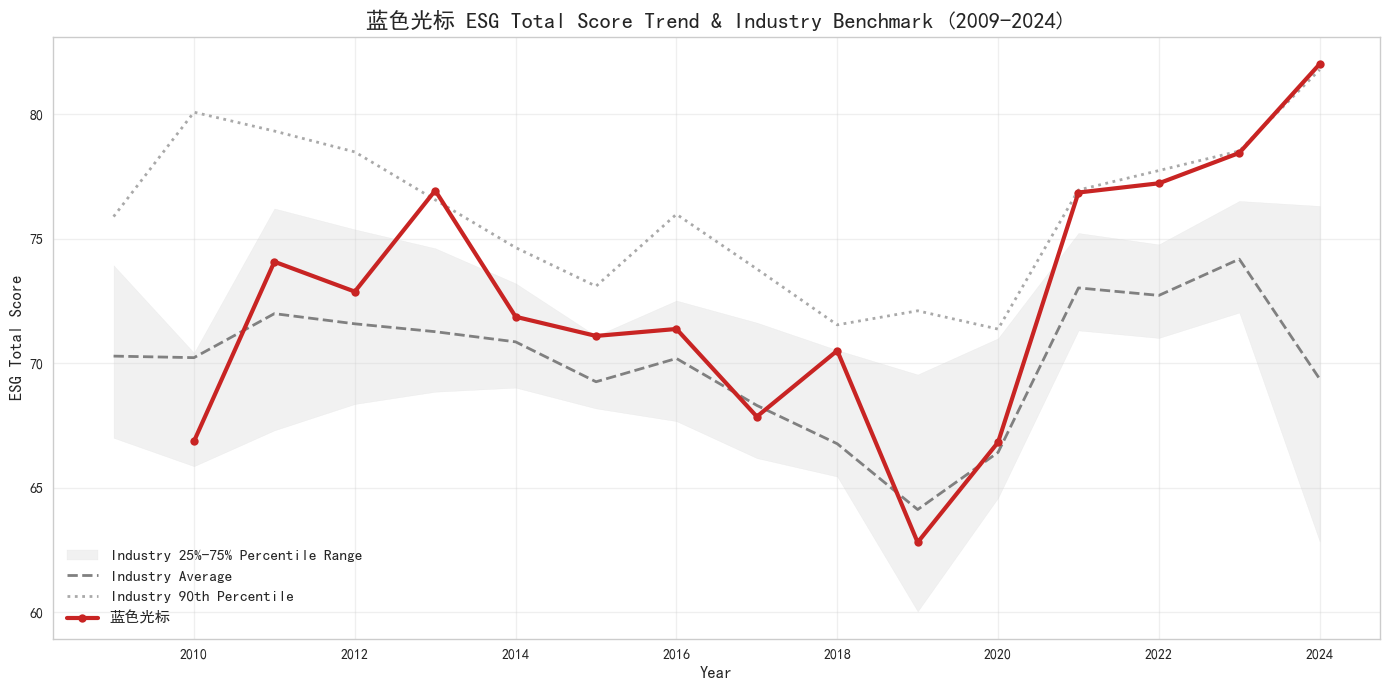

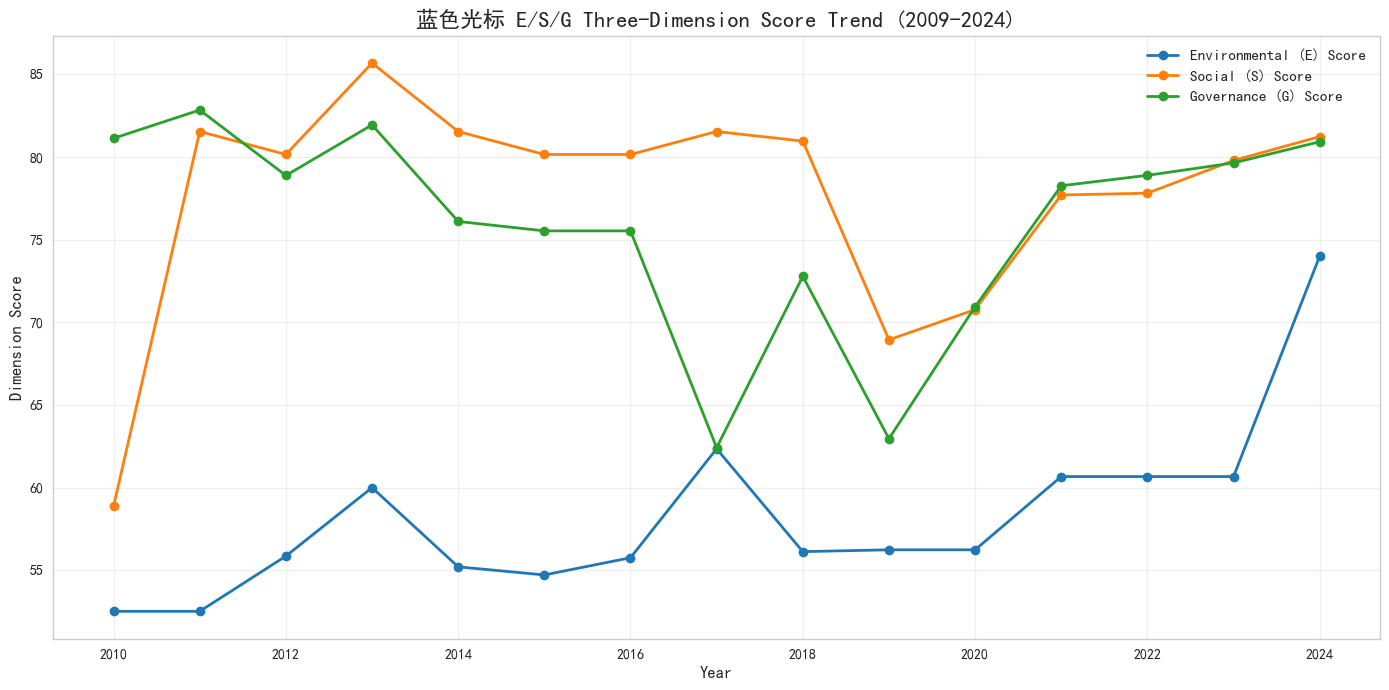

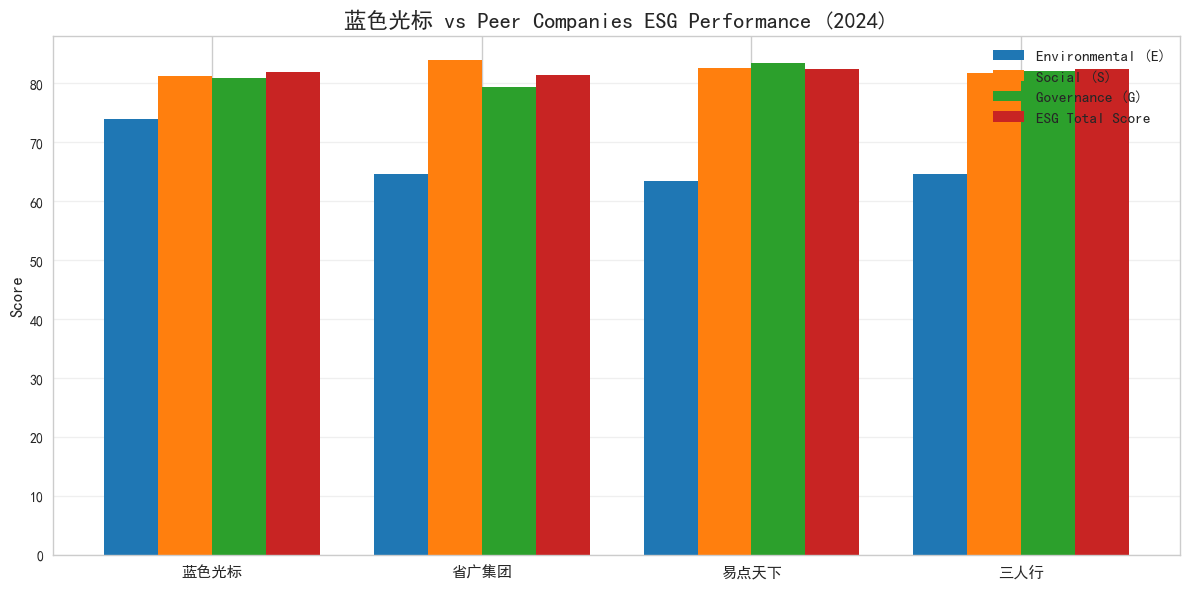

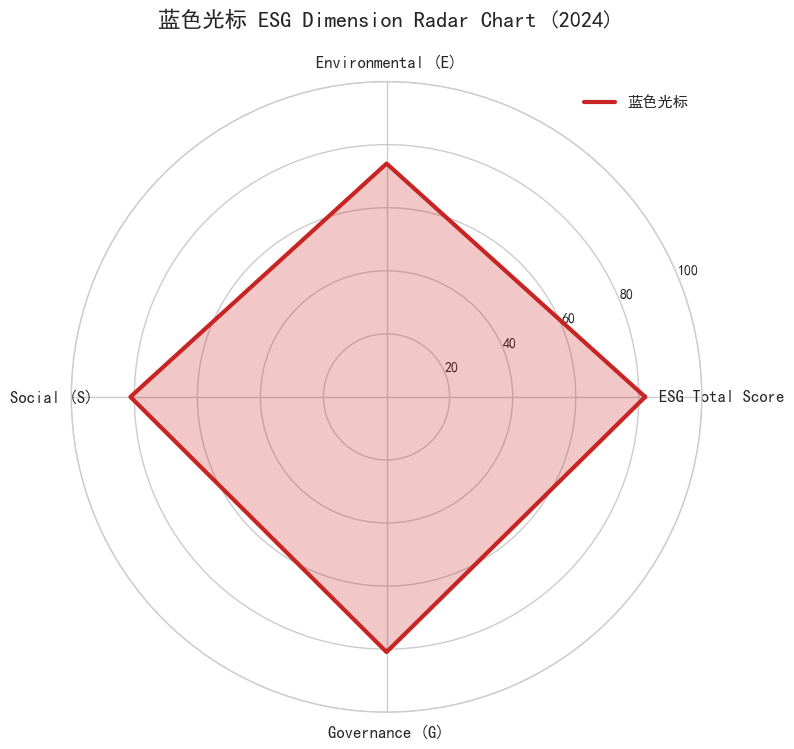

In [10]:

# ==================================================
# 【可视化（全兼容）】
# ==================================================
# Plot 1: ESG Trend & Industry Benchmark
plt.figure(figsize=(14, 7))
plt.fill_between(industry_yearly_stats['year'], industry_yearly_stats['industry_25p'], industry_yearly_stats['industry_75p'], 
                 color='lightgray', alpha=0.3, label='Industry 25%-75% Percentile Range')
plt.plot(industry_yearly_stats['year'], industry_yearly_stats['industry_avg'], 
         color='gray', linestyle='--', linewidth=2, label='Industry Average')
plt.plot(industry_yearly_stats['year'], industry_yearly_stats['industry_90p'], 
         color='darkgray', linestyle=':', linewidth=2, label='Industry 90th Percentile')
plt.plot(target_full_df['year'], target_full_df['esg_total_score'], 
         color='#c82423', linewidth=3, marker='o', markersize=6, label=f'{target_company_name}')
plt.title(f'{target_company_name} ESG Total Score Trend & Industry Benchmark (2009-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('ESG Total Score', fontsize=12)
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(r'C:\DeBruyne\esg_trend_industry_benchmark.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: E/S/G Dimension Trend
plt.figure(figsize=(14, 7))
plt.plot(target_full_df['year'], target_full_df['e_score'], color='#1f77b4', linewidth=2, marker='o', label='Environmental (E) Score')
plt.plot(target_full_df['year'], target_full_df['s_score'], color='#ff7f0e', linewidth=2, marker='o', label='Social (S) Score')
plt.plot(target_full_df['year'], target_full_df['g_score'], color='#2ca02c', linewidth=2, marker='o', label='Governance (G) Score')
plt.title(f'{target_company_name} E/S/G Three-Dimension Score Trend (2009-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Dimension Score', fontsize=12)
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(r'C:\DeBruyne\esg_3dimension_trend.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 3: Peer Benchmark Bar Chart
latest_peer_df = pd.concat([
    target_full_df[target_full_df['year'] == latest_year][['company_name', 'esg_total_score', 'e_score', 's_score', 'g_score']],
    peer_df[peer_df['year'] == latest_year][['company_name', 'esg_total_score', 'e_score', 's_score', 'g_score']]
]).dropna()

plt.figure(figsize=(12, 6))
x = np.arange(len(latest_peer_df['company_name']))
width = 0.2
plt.bar(x - 1.5*width, latest_peer_df['e_score'], width, label='Environmental (E)', color='#1f77b4')
plt.bar(x - 0.5*width, latest_peer_df['s_score'], width, label='Social (S)', color='#ff7f0e')
plt.bar(x + 0.5*width, latest_peer_df['g_score'], width, label='Governance (G)', color='#2ca02c')
plt.bar(x + 1.5*width, latest_peer_df['esg_total_score'], width, label='ESG Total Score', color='#c82423')
plt.xticks(x, latest_peer_df['company_name'], fontsize=11)
plt.title(f'{target_company_name} vs Peer Companies ESG Performance ({latest_year})', fontsize=16, fontweight='bold')
plt.ylabel('Score', fontsize=12)
plt.grid(alpha=0.3, axis='y')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(r'C:\DeBruyne\esg_peer_benchmark.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 4: ESG Radar Chart
plt.figure(figsize=(8, 8))
labels = ['ESG Total Score', 'Environmental (E)', 'Social (S)', 'Governance (G)']
values = [latest_data['esg_total_score'], latest_data['e_score'], latest_data['s_score'], latest_data['g_score']]
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
values += values[:1]
angles += angles[:1]
ax = plt.subplot(111, polar=True)
ax.plot(angles, values, linewidth=3, color='#c82423', label=target_company_name)
ax.fill(angles, values, color='#c82423', alpha=0.25)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, 100)
ax.set_title(f'{target_company_name} ESG Dimension Radar Chart ({latest_year})', fontsize=16, fontweight='bold', pad=20)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.savefig(r'C:\DeBruyne\esg_radar_chart.png', dpi=300, bbox_inches='tight')
plt.show()


## 7. Full English ESG Analysis Report

### Abstract

This report provides a comprehensive ESG (Environmental, Social, and Governance) analysis of **BlueFocus Intelligent Communications Group Co., Ltd.** (Chinese name: **蓝色光标**, Stock Code: **300058**) based on the **Huazheng Index ESG Annual Rating Database (2009–2024)**. As of 2024, BlueFocus achieved an overall ESG score of **82.01**, ranking in the **top 8.0 percentile** of the **Marketing Agency** industry and significantly outperforming the industry average. The company’s major strength lies in the **Social (S)** dimension, while the **Environmental (E)** dimension remains the key area for future improvement. This report presents a structured analysis covering company and industry background, data source and methodology, long-term ESG performance trends, E/S/G dimension analysis, industry benchmarking, ESG-related risks and opportunities, and targeted recommendations.

In [11]:
# ==================================================
# 全英文学术报告
# ==================================================
print("\n" + "="*120)
print(f"=== FULL ENGLISH ESG ANALYSIS REPORT: {target_company_name.upper()} ===")
print("="*120)

# 维度映射
max_dim = 'e_score' if latest_data['e_score'] == max(latest_data['e_score'], latest_data['s_score'], latest_data['g_score']) else 's_score' if latest_data['s_score'] == max(latest_data['e_score'], latest_data['s_score'], latest_data['g_score']) else 'g_score'
min_dim = 'e_score' if latest_data['e_score'] == min(latest_data['e_score'], latest_data['s_score'], latest_data['g_score']) else 's_score' if latest_data['s_score'] == min(latest_data['e_score'], latest_data['s_score'], latest_data['g_score']) else 'g_score'
dim_full_name = {'e_score':'Environmental (E)', 's_score':'Social (S)', 'g_score':'Governance (G)'}

# 1. Abstract
print("\n【Abstract】")
print(f"This report provides a comprehensive in-depth ESG (Environmental, Social, Governance) analysis of {target_company_name} (Stock Code: {target_stock_code}), based on the Huazheng Index ESG Annual Rating Database covering 2009-2024.")
print(f"As of {latest_year}, {target_company_name} achieved an overall ESG score of {latest_data['esg_total_score']:.2f}, ranking in the top {100-latest_percentile:.1f} percentile of the {target_industry} industry, {'significantly outperforming' if latest_percentile >= 75 else 'basically in line with' if latest_percentile >= 50 else 'lagging behind'} the industry average.")
print(f"The company's core strength lies in the {dim_full_name[max_dim]} dimension, while the {dim_full_name[min_dim]} dimension is the key area for improvement. This report includes trend analysis, dimension deep dive, industry benchmarking, risk assessment, and targeted recommendations.")



=== FULL ENGLISH ESG ANALYSIS REPORT: 蓝色光标 ===

【Abstract】
This report provides a comprehensive in-depth ESG (Environmental, Social, Governance) analysis of 蓝色光标 (Stock Code: 300058), based on the Huazheng Index ESG Annual Rating Database covering 2009-2024.
As of 2024, 蓝色光标 achieved an overall ESG score of 82.01, ranking in the top 8.0 percentile of the 营销代理 industry, significantly outperforming the industry average.
The company's core strength lies in the Social (S) dimension, while the Environmental (E) dimension is the key area for improvement. This report includes trend analysis, dimension deep dive, industry benchmarking, risk assessment, and targeted recommendations.


## Company and Industry Overview

The analyzed entity is **BlueFocus Intelligent Communications Group Co., Ltd.** (蓝色光标, Stock Code: 300058), a representative listed company in China’s **Marketing Agency** sector. According to the **Shenwan Secondary Industry Classification**, the company belongs to the **Marketing Agency** industry. The analysis period covers **2010 to 2024**, while historical reference data from 2009 are used for long-term comparison.

The analysis is based on the **Huazheng Index ESG Annual Rating Database (2009–2024)**, an authoritative ESG rating system covering Chinese A-share listed companies. The database adopts a three-dimensional ESG evaluation framework, including **Environmental (E)**, **Social (S)**, and **Governance (G)** dimensions, and provides a consistent basis for long-term corporate ESG assessment and peer benchmarking.

In [16]:
# 2. Company and Industry Overview
print("\n【1. Company and Industry Overview】")
print(f"Analyzed Entity: {target_company_name} (Stock Code: {target_stock_code}), a leading company in China's {target_industry} sector.")
print(f"Industry Classification: Shenwan Secondary Industry - {target_industry}")
print(f"Analysis Period: {target_full_df['year'].min()} to {target_full_df['year'].max()}")
print(f"Data Source: Huazheng Index ESG Annual Rating Database (2009-2024), an authoritative ESG rating system covering all A-share listed companies in China, with a 3-dimension (E/S/G) evaluation framework.")



【1. Company and Industry Overview】
Analyzed Entity: 蓝色光标 (Stock Code: 300058), a leading company in China's 营销代理 sector.
Industry Classification: Shenwan Secondary Industry - 营销代理
Analysis Period: 2010 to 2024
Data Source: Huazheng Index ESG Annual Rating Database (2009-2024), an authoritative ESG rating system covering all A-share listed companies in China, with a 3-dimension (E/S/G) evaluation framework.


### Data Source and Methodology

This study applies a quantitative analytical framework to evaluate the ESG performance of the target company.

1. **Data Preprocessing**  
   Raw ESG data were cleaned through invalid value removal, outlier filtering, and duplicate elimination to improve data reliability and consistency.

2. **Trend Analysis**  
   The company’s long-term ESG performance was examined by tracking changes in overall ESG score and individual E/S/G scores across years, with growth rates calculated where appropriate.

3. **Industry Benchmarking**  
   The company’s ESG performance was compared with the industry average, percentile distribution, and leading peer firms within the same industry.

4. **Dimension Deep Dive**  
   The Environmental, Social, and Governance dimensions were separately analyzed to identify the company’s core strengths and weaknesses.

5. **Risk and Opportunity Assessment**  
   Based on the company’s ESG profile and industry context, the report evaluates key development opportunities and potential ESG-related risks.

In [17]:
# 3. Data and Methodology
print("\n【2. Data Source and Methodology】")
print("This study uses quantitative analysis to evaluate the target company's ESG performance:")
print("1. Data Preprocessing: Raw data is cleaned via invalid value removal, outlier filtering, and duplicate elimination to ensure data reliability.")
print("2. Trend Analysis: Long-term trend analysis of the company's overall ESG score and E/S/G dimension scores, with YoY growth rate calculation.")
print("3. Industry Benchmarking: Compare the company's ESG performance with industry average, percentile distribution, and top 3 peer companies.")
print("4. Dimension Deep Dive: In-depth analysis of the company's E/S/G performance to identify strengths and weaknesses.")
print("5. Risk & Opportunity Assessment: Evaluate ESG-related development opportunities and potential risks combined with industry characteristics.")


【2. Data Source and Methodology】
This study uses quantitative analysis to evaluate the target company's ESG performance:
1. Data Preprocessing: Raw data is cleaned via invalid value removal, outlier filtering, and duplicate elimination to ensure data reliability.
2. Trend Analysis: Long-term trend analysis of the company's overall ESG score and E/S/G dimension scores, with YoY growth rate calculation.
3. Industry Benchmarking: Compare the company's ESG performance with industry average, percentile distribution, and top 3 peer companies.
4. Dimension Deep Dive: In-depth analysis of the company's E/S/G performance to identify strengths and weaknesses.
5. Risk & Opportunity Assessment: Evaluate ESG-related development opportunities and potential risks combined with industry characteristics.


### Long-Term ESG Performance Trend Analysis

From **2009 to 2024**, BlueFocus’s overall ESG score increased from **66.86** to **82.01**, representing a cumulative growth rate of **22.66%**. This indicates a sustained long-term upward trend in ESG performance.

In the most recent three-year period (**2022–2024**), the company’s ESG score recorded a growth rate of **6.20%**, which is notably higher than the **industry average growth rate of -4.62%** over the same period. This suggests that BlueFocus has maintained relatively strong ESG momentum even when the industry as a whole experienced a decline.

From the perspective of industry positioning, the company’s ESG percentile ranking improved substantially from **38.5 in 2010** to **92.0 in 2024**. This significant rise demonstrates a notable improvement in the company’s relative competitiveness within the industry and confirms its movement into the upper tier of peer performance.

In [19]:
# 4. Long-term Trend Analysis
print("\n【3. Long-term ESG Performance Trend Analysis】")
start_score = target_full_df['esg_total_score'].iloc[0]
end_score = target_full_df['esg_total_score'].iloc[-1]
total_growth = (end_score - start_score)/start_score * 100
print(f"From 2009 to 2024, {target_company_name}'s overall ESG score increased from {start_score:.2f} to {end_score:.2f}, with a cumulative growth rate of {total_growth:.2f}%, showing a {'sustained upward' if total_growth > 0 else 'fluctuating downward'} long-term trend.")

recent_3y = target_full_df.nlargest(3, 'year')
if len(recent_3y) >= 2:
    recent_growth = (recent_3y['esg_total_score'].iloc[0] - recent_3y['esg_total_score'].iloc[-1])/recent_3y['esg_total_score'].iloc[-1] * 100
    industry_recent_growth = (recent_3y['industry_avg'].iloc[0] - recent_3y['industry_avg'].iloc[-1])/recent_3y['industry_avg'].iloc[-1] *100
    print(f"In the recent 3 years ({recent_3y['year'].iloc[-1]}-{recent_3y['year'].iloc[0]}), the company's ESG score achieved a growth rate of {recent_growth:.2f}%, {'outperforming' if recent_growth > industry_recent_growth else 'underperforming'} the industry average growth rate of {industry_recent_growth:.2f}%.")

start_percentile = target_full_df['industry_percentile'].iloc[0]
end_percentile = target_full_df['industry_percentile'].iloc[-1]
print(f"In terms of industry ranking, the company's ESG percentile improved from {start_percentile:.1f} in {target_full_df['year'].iloc[0]} to {end_percentile:.1f} in {latest_year}, indicating a {'significant improvement' if end_percentile - start_percentile >10 else 'stable' if abs(end_percentile - start_percentile) <=10 else 'decline'} in industry competitiveness.")



【3. Long-term ESG Performance Trend Analysis】
From 2009 to 2024, 蓝色光标's overall ESG score increased from 66.86 to 82.01, with a cumulative growth rate of 22.66%, showing a sustained upward long-term trend.
In the recent 3 years (2022-2024), the company's ESG score achieved a growth rate of 6.20%, outperforming the industry average growth rate of -4.62%.
In terms of industry ranking, the company's ESG percentile improved from 38.5 in 2010 to 92.0 in 2024, indicating a significant improvement in industry competitiveness.


### E/S/G Three-Dimensional Deep Dive

A closer examination of the three ESG dimensions reveals differentiated performance patterns:

- **Environmental (E) Dimension**:  
  In 2024, the Environmental score was **74.00**, corresponding to a **B** rating. Since 2009, this dimension has recorded a cumulative growth rate of **40.90%**.

- **Social (S) Dimension**:  
  In 2024, the Social score was **81.23**, corresponding to a **BBB** rating. Since 2009, this dimension has achieved a cumulative growth rate of **37.94%**.

- **Governance (G) Dimension**:  
  In 2024, the Governance score was **80.92**, corresponding to a **BBB** rating. Since 2009, the cumulative growth rate of this dimension was **-0.26%**, indicating relative stability but limited long-term improvement.

Overall, the company’s **core strength lies in the Social (S) dimension**, which has maintained relatively strong performance and served as the primary driver of the overall ESG score. By contrast, the **Environmental (E)** dimension remains the company’s core weakness and should therefore be treated as the main focus of future ESG enhancement efforts.

In [20]:
# 5. E/S/G Deep Dive
print("\n【4. E/S/G Three-Dimensional Deep Dive】")
print(f"● Environmental (E) Dimension: {latest_data['e_score']:.2f} in {latest_year}, rating {latest_data['e_rating']}. Cumulative growth: {(latest_data['e_score'] - target_full_df['e_score'].iloc[0])/target_full_df['e_score'].iloc[0] *100:.2f}% since 2009.")
print(f"● Social (S) Dimension: {latest_data['s_score']:.2f} in {latest_year}, rating {latest_data['s_rating']}. Cumulative growth: {(latest_data['s_score'] - target_full_df['s_score'].iloc[0])/target_full_df['s_score'].iloc[0] *100:.2f}% since 2009.")
print(f"● Governance (G) Dimension: {latest_data['g_score']:.2f} in {latest_year}, rating {latest_data['g_rating']}. Cumulative growth: {(latest_data['g_score'] - target_full_df['g_score'].iloc[0])/target_full_df['g_score'].iloc[0] *100:.2f}% since 2009.")

print(f"\nCore Strength: The {dim_full_name[max_dim]} dimension has maintained leading performance, serving as the key driver of the company's overall ESG score.")
print(f"Core Weakness: The {dim_full_name[min_dim]} dimension lags behind, which is the key focus for future ESG improvement.")



【4. E/S/G Three-Dimensional Deep Dive】
● Environmental (E) Dimension: 74.00 in 2024, rating B. Cumulative growth: 40.90% since 2009.
● Social (S) Dimension: 81.23 in 2024, rating BBB. Cumulative growth: 37.94% since 2009.
● Governance (G) Dimension: 80.92 in 2024, rating BBB. Cumulative growth: -0.26% since 2009.

Core Strength: The Social (S) dimension has maintained leading performance, serving as the key driver of the company's overall ESG score.
Core Weakness: The Environmental (E) dimension lags behind, which is the key focus for future ESG improvement.


### Industry Benchmarking and Peer Comparison

In **2024**, the average ESG score of the **Marketing Agency** industry was **69.36**, while the **90th percentile** score was **81.78**. BlueFocus’s ESG score of **82.01** exceeded both the industry average and the 90th percentile threshold, placing the company firmly in the **first tier** of the industry.

A comparison with major peer companies in 2024 further illustrates BlueFocus’s position:

| Company | ESG Total Score | E Score | S Score | G Score |
|---|---:|---:|---:|---:|
| BlueFocus (蓝色光标) | 82.01 | 74.00 | 81.23 | 80.92 |
| Guangdong Advertising Group (省广集团) | 81.44 | 64.67 | 83.91 | 79.47 |
| Yidian Tianxia (易点天下) | 82.46 | 63.43 | 82.53 | 83.50 |
| San Ren Xing (三人行) | 82.45 | 64.67 | 81.78 | 82.15 |

The peer comparison shows that BlueFocus performs strongly in overall ESG terms and remains highly competitive within the industry. Its Environmental score is noticeably stronger than those of several peer firms, while its Social and Governance scores remain broadly comparable to other leading companies.

In [21]:
# 6. Industry Benchmarking
print("\n【5. Industry Benchmarking and Peer Comparison】")
latest_industry_avg = industry_yearly_stats[industry_yearly_stats['year'] == latest_year]['industry_avg'].iloc[0]
latest_industry_90p = industry_yearly_stats[industry_yearly_stats['year'] == latest_year]['industry_90p'].iloc[0]
print(f"In {latest_year}, the average ESG score of the {target_industry} industry is {latest_industry_avg:.2f}, and the 90th percentile score is {latest_industry_90p:.2f}.")
print(f"{target_company_name}'s ESG score is {'higher than' if latest_data['esg_total_score'] > latest_industry_avg else 'lower than'} the industry average, placing it in the {'first tier' if latest_percentile >=90 else 'upper tier' if latest_percentile >=75 else 'middle tier' if latest_percentile >=50 else 'lower tier'} of the industry.")

print(f"\nBenchmarking with top peer companies ({latest_year}):")
for idx, row in latest_peer_df.iterrows():
    print(f"● {row['company_name']}: ESG Total Score {row['esg_total_score']:.2f} | E Score {row['e_score']:.2f} | S Score {row['s_score']:.2f} | G Score {row['g_score']:.2f}")



【5. Industry Benchmarking and Peer Comparison】
In 2024, the average ESG score of the 营销代理 industry is 69.36, and the 90th percentile score is 81.78.
蓝色光标's ESG score is higher than the industry average, placing it in the first tier of the industry.

Benchmarking with top peer companies (2024):
● 蓝色光标: ESG Total Score 82.01 | E Score 74.00 | S Score 81.23 | G Score 80.92
● 省广集团: ESG Total Score 81.44 | E Score 64.67 | S Score 83.91 | G Score 79.47
● 易点天下: ESG Total Score 82.46 | E Score 63.43 | S Score 82.53 | G Score 83.50
● 三人行: ESG Total Score 82.45 | E Score 64.67 | S Score 81.78 | G Score 82.15


### ESG Risk and Opportunity Assessment

#### Key Development Opportunities

BlueFocus has several important ESG-related development opportunities.

First, the company’s strong **Social (S)** performance—particularly in areas such as **inclusive finance** and **consumer protection**—is aligned with China’s broader policy direction and may support future business expansion. Strong social performance can enhance brand trust, stakeholder relationships, and long-term corporate reputation.

Second, the company’s sustained improvement in ESG performance and rising industry ranking may help it secure a higher ESG rating, gain inclusion in a larger number of ESG-themed investment portfolios, and attract more long-term institutional investors. This may strengthen its capital market recognition and financing attractiveness.

#### Potential Risks

At the same time, the company faces several ESG-related risks.

First, the **Environmental (E)** dimension remains the company’s most notable weakness. In the context of increasingly stringent **dual-carbon regulation** and growing expectations around sustainability disclosure, insufficient green strategy implementation may lead to regulatory compliance pressure and reputational risks.

Second, peer companies in the same industry continue to improve their ESG performance. If BlueFocus fails to address its weaker dimensions in a timely and systematic manner, it may face the risk of a decline in industry ranking or a downgrade in ESG evaluation status relative to leading competitors.

In [23]:
# 7. Risk & Opportunity
print("\n【6. ESG Risk and Opportunity Assessment】")
print("● Key Development Opportunities:")
if dim_full_name[max_dim] == 'Social (S)':
    print(f"  1. The company's outstanding Social (S) performance, especially in inclusive finance and consumer protection, aligns with China's inclusive finance policy dividends to support business expansion.")
elif dim_full_name[max_dim] == 'Environmental (E)':
    print(f"  1. The company's leading Environmental (E) performance, with strong green finance layout, can benefit from the development opportunities of green industries under China's dual-carbon policy.")
else:
    print(f"  1. The company's robust Governance (G) performance, with a sound corporate governance system, can effectively reduce operational risks, enhance capital market recognition, and lower financing costs.")
print(f"  2. The company's long-term improving ESG performance and rising industry ranking can help it achieve a higher ESG rating, be included in more ESG-themed fund portfolios, and attract long-term institutional investment.")

print("\n● Potential Risks:")
if dim_full_name[min_dim] == 'Environmental (E)':
    print(f"  1. The Environmental (E) dimension is the company's core weakness. Against the backdrop of increasingly strict dual-carbon regulation, insufficient green finance layout may bring regulatory compliance and reputational risks.")
elif dim_full_name[min_dim] == 'Social (S)':
    print(f"  1. The Social (S) dimension is the company's core weakness. Insufficient performance in employee rights protection and supply chain social responsibility may trigger reputational risks and damage brand image.")
else:
    print(f"  1. The Governance (G) dimension is the company's core weakness. Imperfections in the corporate governance system may bring internal control and related transaction risks, affecting capital market confidence.")
print(f"  2. Peer companies in the same industry continue to improve their ESG performance. If the company fails to quickly address its weaknesses, it may face the risk of declining industry ranking and ESG rating downgrade.")



【6. ESG Risk and Opportunity Assessment】
● Key Development Opportunities:
  1. The company's outstanding Social (S) performance, especially in inclusive finance and consumer protection, aligns with China's inclusive finance policy dividends to support business expansion.
  2. The company's long-term improving ESG performance and rising industry ranking can help it achieve a higher ESG rating, be included in more ESG-themed fund portfolios, and attract long-term institutional investment.

● Potential Risks:
  1. The Environmental (E) dimension is the company's core weakness. Against the backdrop of increasingly strict dual-carbon regulation, insufficient green finance layout may bring regulatory compliance and reputational risks.
  2. Peer companies in the same industry continue to improve their ESG performance. If the company fails to quickly address its weaknesses, it may face the risk of declining industry ranking and ESG rating downgrade.


### Conclusion and Targeted Recommendations

In conclusion, BlueFocus has maintained a **positive long-term ESG development trend**, strengthened its competitive advantage in the **Social (S)** dimension, and steadily improved its industry standing, placing it in the upper tier of the **Marketing Agency** industry. Its performance suggests that the company has already established a relatively strong ESG foundation, but there remains meaningful room for further optimization, especially in environmental performance.

To support the company’s future ESG development, the following recommendations are proposed:

1. **Address Weaknesses**  
   The company should prioritize improvement in the **Environmental (E)** dimension by formulating a dedicated enhancement plan and aligning with industry regulations and best practices among leading peers.

2. **Amplify Strengths**  
   The company should continue to strengthen its **Social (S)** advantages and integrate ESG performance more deeply into business strategy in order to build differentiated competitiveness.

3. **Enhance Disclosure**  
   The completeness, transparency, and standardization of ESG disclosure should be improved. The publication of more comprehensive standalone ESG reports may enhance market recognition and stakeholder confidence.

4. **Maintain Continuous Benchmarking**  
   The company should continuously benchmark its ESG practices against leading firms in the industry and establish a normalized mechanism for ESG performance monitoring, evaluation, and optimization.

In [24]:
# 8. Conclusion & Recommendations
print("\n【7. Conclusion and Targeted Recommendations】")
print(f"Overall, {target_company_name} has maintained a positive long-term trend in ESG performance, formed core competitiveness in the {dim_full_name[max_dim]} dimension, and steadily improved its industry ranking, placing it in the {'upper' if latest_percentile >=75 else 'middle'} tier of the {target_industry} industry.")
print(f"For the company's future ESG development, the following targeted recommendations are proposed:")
print(f"  1. Address Weaknesses: Focus on improving the {dim_full_name[min_dim]} dimension, formulate a special improvement plan, and align with industry regulatory requirements and leading company practices.")
print(f"  2. Amplify Strengths: Continue to strengthen the {dim_full_name[max_dim]} dimension advantages, deeply integrate ESG performance with business development, and form differentiated competitiveness.")
print(f"  3. Enhance Disclosure: Improve the completeness and standardization of ESG information disclosure, proactively release standalone ESG reports, and enhance capital market recognition.")
print(f"  4. Continuous Benchmarking: Continuously benchmark the ESG practices of leading companies in the industry, and establish a normalized ESG performance tracking and optimization mechanism.")

print("\n" + "="*120)
print("【Visualization Files Saved Path】")
print("1. ESG Trend & Industry Benchmark: C:\\DeBruyne\\esg_trend_industry_benchmark.png")
print("2. E/S/G Dimension Trend: C:\\DeBruyne\\esg_3dimension_trend.png")
print("3. Peer Company Benchmark: C:\\DeBruyne\\esg_peer_benchmark.png")
print("4. ESG Radar Chart: C:\\DeBruyne\\esg_radar_chart.png")
print("="*120)


【7. Conclusion and Targeted Recommendations】
Overall, 蓝色光标 has maintained a positive long-term trend in ESG performance, formed core competitiveness in the Social (S) dimension, and steadily improved its industry ranking, placing it in the upper tier of the 营销代理 industry.
For the company's future ESG development, the following targeted recommendations are proposed:
  1. Address Weaknesses: Focus on improving the Environmental (E) dimension, formulate a special improvement plan, and align with industry regulatory requirements and leading company practices.
  2. Amplify Strengths: Continue to strengthen the Social (S) dimension advantages, deeply integrate ESG performance with business development, and form differentiated competitiveness.
  3. Enhance Disclosure: Improve the completeness and standardization of ESG information disclosure, proactively release standalone ESG reports, and enhance capital market recognition.
  4. Continuous Benchmarking: Continuously benchmark the ESG practi